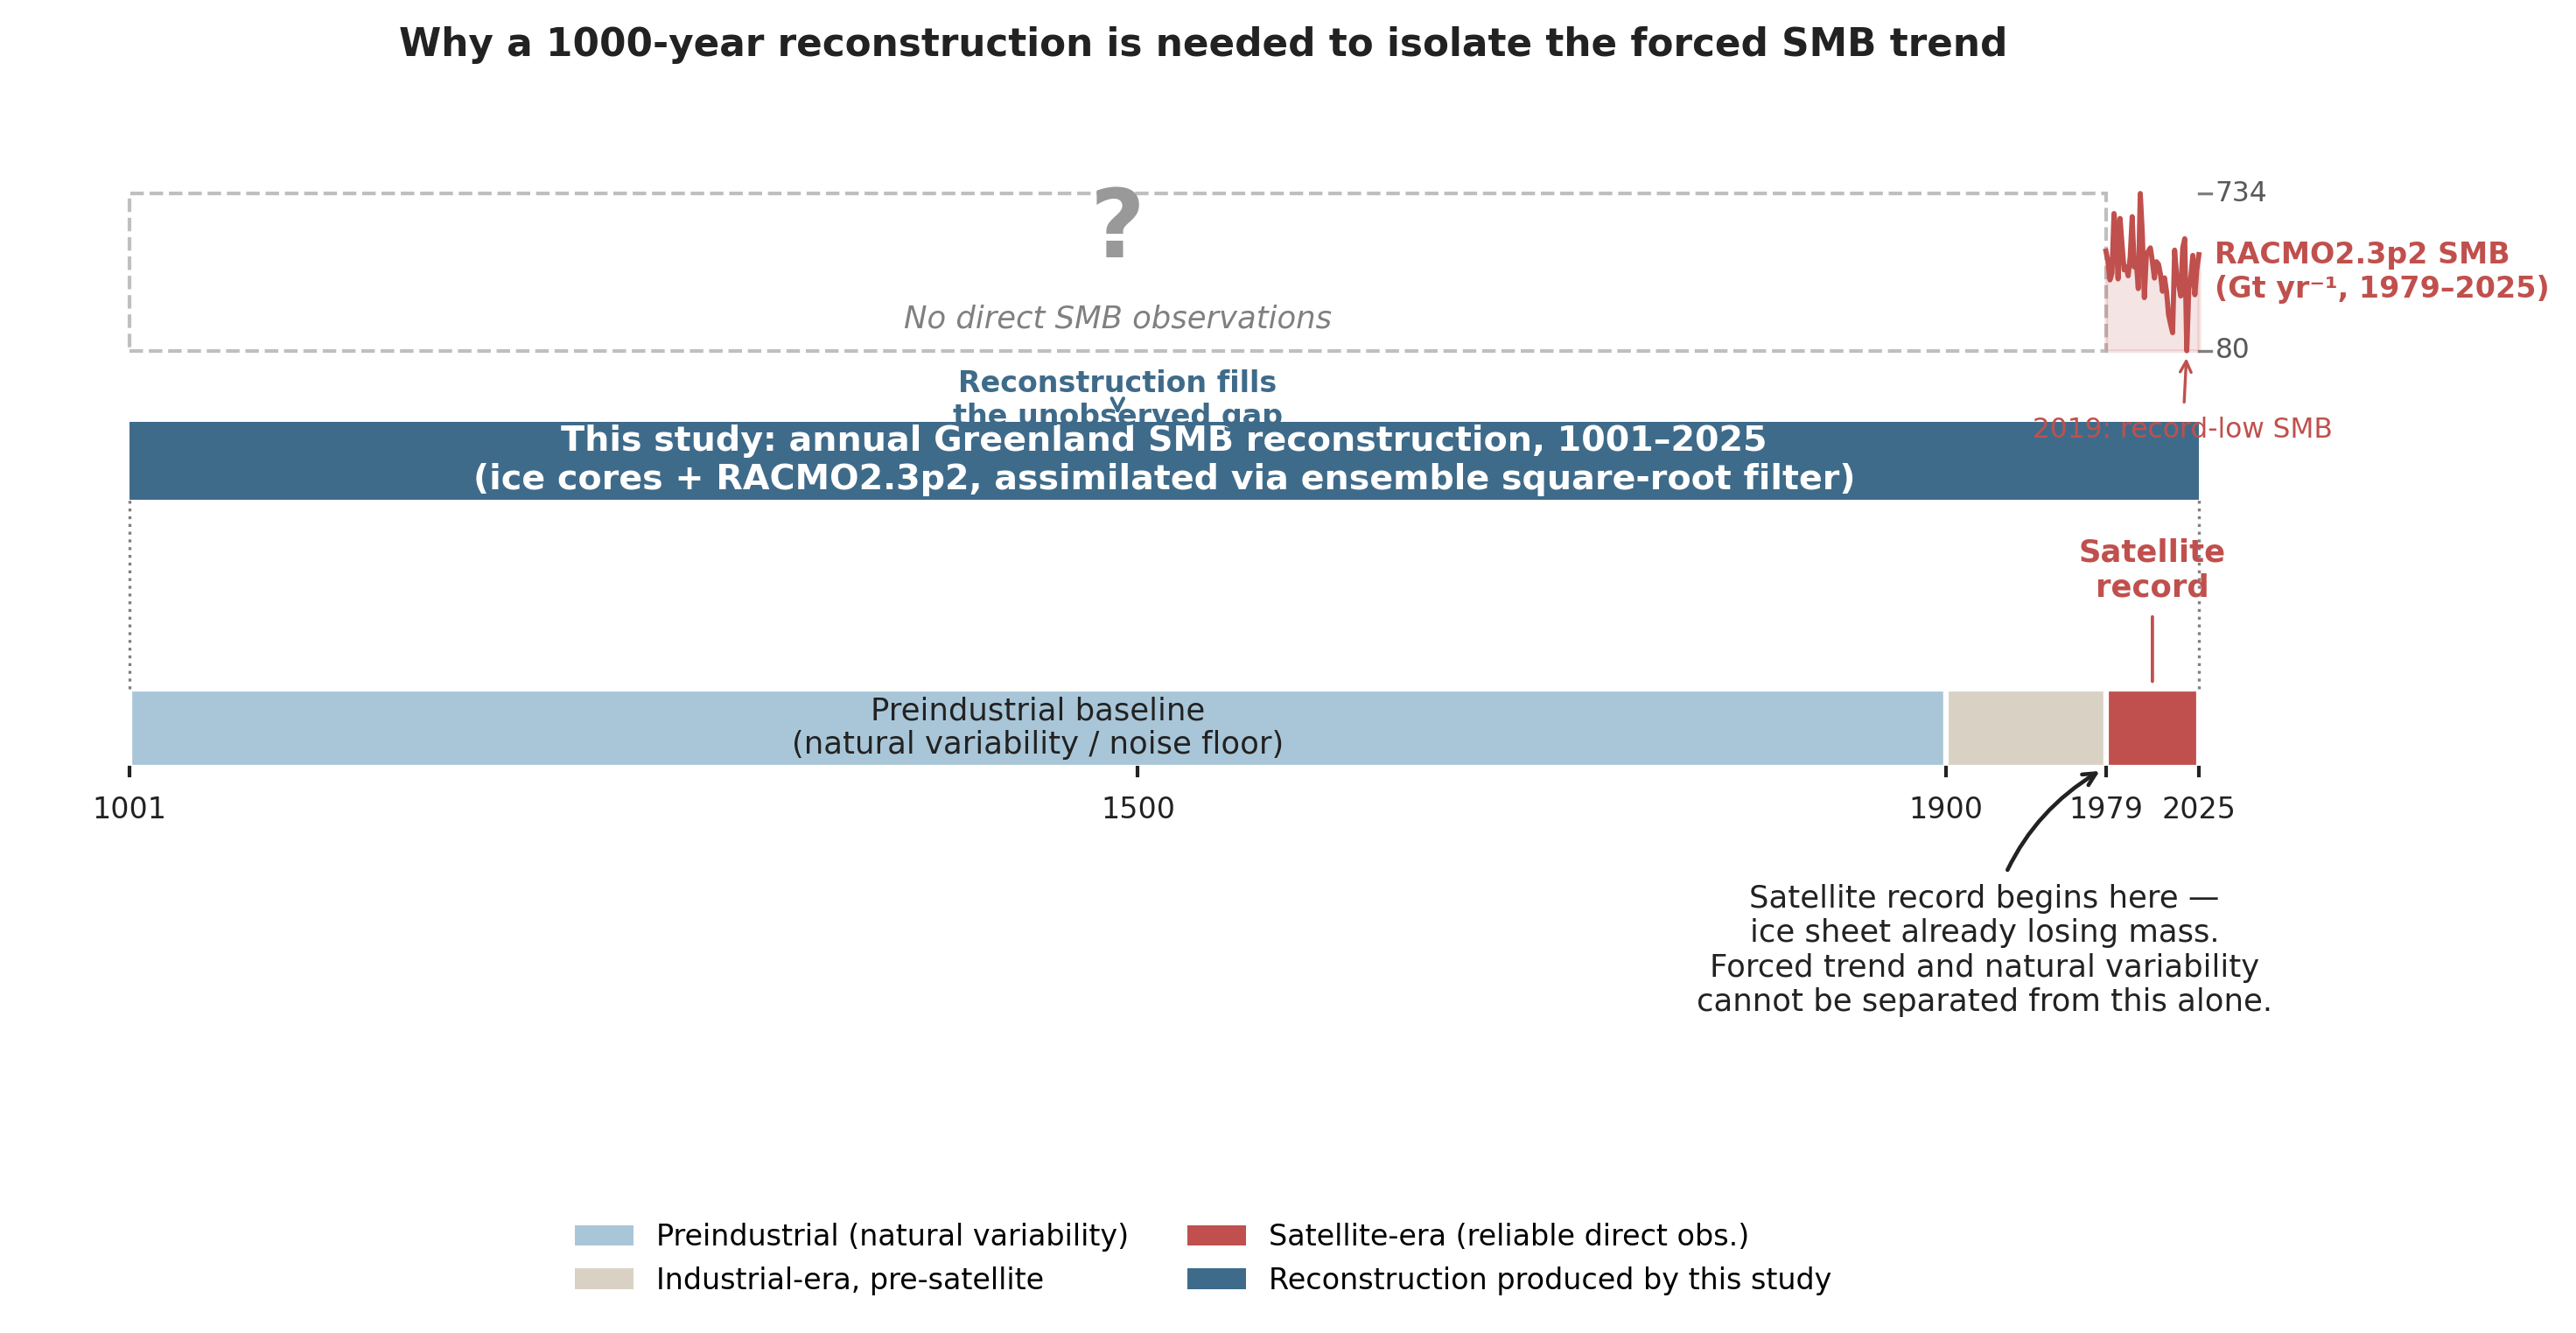

In [4]:
import numpy as np, os
import matplotlib.pyplot as plt
import matplotlib.patches as patches

YEAR_START, YEAR_END, SATELLITE_START, PREINDUSTRIAL_END = 1001, 2025, 1979, 1900
c_reconstruction, c_preindustrial = "#3F6B8A", "#A9C6D8"
c_transition, c_satellite, c_text = "#D9D2C4", "#C0504D", "#222222"

# ---- REAL RACMO2.3p2 Greenland SMB, 1979–2025 ----
_g = np.load(os.path.expanduser("~/DataFiles/GRN_smb_annual_Gt.npy"))
gyrs, gsmb = _g[0].astype(int), _g[1]
m = (gyrs >= SATELLITE_START) & (gyrs <= YEAR_END)
yrs, smb_vals = gyrs[m], gsmb[m]

fig, ax = plt.subplots(figsize=(10, 5.2), dpi=300)
bar_y, bar_height, recon_y = 0.5, 0.5, 2.2

# ---- SMB overlay band (top): real curve 1979–2025, blank to the left ----
cy0, cy1 = 3.15, 4.15
vmin, vmax = smb_vals.min(), smb_vals.max()
curve_y = cy0 + (smb_vals - vmin) / (vmax - vmin) * (cy1 - cy0)
ax.plot(yrs, curve_y, color=c_satellite, lw=1.4, zorder=5)
ax.fill_between(yrs, cy0, curve_y, color=c_satellite, alpha=0.15, zorder=4)
# real-magnitude ticks on the right
for val, yy in [(vmax, cy1), (vmin, cy0)]:
    ax.plot([YEAR_END, YEAR_END + 6], [cy0 + (val-vmin)/(vmax-vmin)*(cy1-cy0)]*2, color="0.5", lw=0.8)
    ax.text(YEAR_END + 8, cy0 + (val-vmin)/(vmax-vmin)*(cy1-cy0), f"{val:.0f}", ha="left", va="center", fontsize=7.5, color="0.35")
ax.text(YEAR_END + 8, (cy0+cy1)/2, "RACMO2.3p2 SMB\n(Gt yr⁻¹, 1979–2025)", ha="left", va="center",
        fontsize=8, color=c_satellite, fontweight="bold")
# annotate the record-low melt year
iy = int(np.argmin(smb_vals))
ax.annotate(f"{yrs[iy]}: record-low SMB", xy=(yrs[iy], curve_y[iy]), xytext=(yrs[iy]-2, cy0-0.42),
            ha="center", va="top", fontsize=7.5, color=c_satellite,
            arrowprops=dict(arrowstyle="->", color=c_satellite, lw=0.8))
# blank space to the left — the unobserved past
ax.add_patch(patches.Rectangle((YEAR_START, cy0), SATELLITE_START-YEAR_START, cy1-cy0,
                               facecolor="none", edgecolor="0.75", lw=1.0, ls="--", zorder=3))
ax.text((YEAR_START + SATELLITE_START)/2, (cy0+cy1)/2 + 0.26, "?", ha="center", va="center", fontsize=26, color="0.6", fontweight="bold")
ax.text((YEAR_START + SATELLITE_START)/2, (cy0+cy1)/2 - 0.30, "No direct SMB observations", ha="center", va="center",
        fontsize=8.5, color="0.5", style="italic")

# ---- Row 1: full reconstruction span ----
ax.add_patch(patches.Rectangle((YEAR_START, recon_y), YEAR_END-YEAR_START, bar_height, facecolor=c_reconstruction, edgecolor="none"))
ax.text((YEAR_START+YEAR_END)/2, recon_y + bar_height/2,
        "This study: annual Greenland SMB reconstruction, 1001–2025\n"
        "(ice cores + RACMO2.3p2, assimilated via ensemble square-root filter)",
        ha="center", va="center", color="white", fontsize=9.5, fontweight="bold")

# ---- Row 2: composition of the record ----
ax.add_patch(patches.Rectangle((YEAR_START, bar_y), PREINDUSTRIAL_END-YEAR_START, bar_height, facecolor=c_preindustrial, edgecolor="white", linewidth=1.5))
ax.text((YEAR_START+PREINDUSTRIAL_END)/2, bar_y+bar_height/2, "Preindustrial baseline\n(natural variability / noise floor)", ha="center", va="center", color=c_text, fontsize=8.5)
ax.add_patch(patches.Rectangle((PREINDUSTRIAL_END, bar_y), SATELLITE_START-PREINDUSTRIAL_END, bar_height, facecolor=c_transition, edgecolor="white", linewidth=1.5))
ax.add_patch(patches.Rectangle((SATELLITE_START, bar_y), YEAR_END-SATELLITE_START, bar_height, facecolor=c_satellite, edgecolor="white", linewidth=1.5))
ax.annotate("Satellite\nrecord", xy=((SATELLITE_START+YEAR_END)/2, bar_y+bar_height), xytext=((SATELLITE_START+YEAR_END)/2, 1.55),
            ha="center", va="bottom", fontsize=8.5, fontweight="bold", color=c_satellite, arrowprops=dict(arrowstyle="-", color=c_satellite, lw=0.9))

# ---- connectors: blank gap → reconstruction fills it ----
for x in [YEAR_START, YEAR_END]:
    ax.plot([x, x], [bar_y+bar_height, recon_y], color="gray", lw=0.8, ls=":")
ax.annotate("Reconstruction fills\nthe unobserved gap", xy=((YEAR_START+SATELLITE_START)/2, recon_y+bar_height),
            xytext=((YEAR_START+SATELLITE_START)/2, cy0-0.12), ha="center", va="top", fontsize=8, color=c_reconstruction,
            fontweight="bold", arrowprops=dict(arrowstyle="->", color=c_reconstruction, lw=1.0))

# ---- key annotation ----
ax.annotate("Satellite record begins here —\nice sheet already losing mass.\nForced trend and natural variability\ncannot be separated from this alone.",
            xy=(SATELLITE_START, bar_y), xytext=(SATELLITE_START-60, -1.05), fontsize=8.5, ha="center", color=c_text,
            arrowprops=dict(arrowstyle="->", color=c_text, lw=1.1, connectionstyle="arc3,rad=-0.25"))

# ---- axis ----
ax.set_xlim(950, 2115); ax.set_ylim(-1.6, 4.7); ax.set_yticks([])
for year in [1001, 1500, 1900, 1979, 2025]:
    ax.plot([year, year], [bar_y-0.05, bar_y], color=c_text, lw=1)
    ax.text(year, bar_y-0.18, str(year), ha="center", va="top", fontsize=8, color=c_text)
ax.spines[["top","right","left","bottom"]].set_visible(False); ax.set_xticks([])

legend_elements = [patches.Patch(facecolor=c_preindustrial, label="Preindustrial (natural variability)"),
                   patches.Patch(facecolor=c_transition, label="Industrial-era, pre-satellite"),
                   patches.Patch(facecolor=c_satellite, label="Satellite-era (reliable direct obs.)"),
                   patches.Patch(facecolor=c_reconstruction, label="Reconstruction produced by this study")]
ax.legend(handles=legend_elements, loc="upper center", bbox_to_anchor=(0.5, -0.10), ncol=2, frameon=False, fontsize=8)
ax.set_title("Why a 1000-year reconstruction is needed to isolate the forced SMB trend", fontsize=10.5, fontweight="bold", color=c_text, pad=14)
plt.tight_layout()
